In [26]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt


from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    FunctionTransformer
)

from sklearn.ensemble import HistGradientBoostingRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error
)

### Carga del pipeline exportado

In [12]:
df = pd.read_csv("./Data/ModelReady/fruit_prices_clean.csv")

In [13]:
pipeline = joblib.load("hist_gradient_boosting.pkl")

###  Train test split

In [14]:
X = df.drop(columns="precio_promedio")
y = df["precio_promedio"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### búsqueda de hiperparámetros.

Para esto utilizaré Random Search

Nota: la lista de parametros es acorde al modelo que seleccionamos para entrenar, en esteo caso: Hist Gradient Boosting. 

In [16]:
param_dist = {

    "model__learning_rate":[
        0.01,
        0.03,
        0.05,
        0.1
    ],

    "model__max_depth":[
        None,
        5,
        10,
        20
    ],

    "model__max_leaf_nodes":[
        15,
        31,
        63
    ],

    "model__min_samples_leaf":[
        20,
        30,
        50
    ],

    "model__max_iter":[
        100,
        200,
        300
    ]

}

In [17]:
search = RandomizedSearchCV(

    estimator=pipeline,

    param_distributions=param_dist,

    n_iter=25,

    cv=5,

    scoring="neg_root_mean_squared_error",

    random_state=42,

    n_jobs=-1

)

In [18]:
search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [None, 5, ...], 'model__max_iter': [100, 200, ...], 'model__max_leaf_nodes': [15, 31, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` direct

In [19]:
search.best_params_

{'model__min_samples_leaf': 50,
 'model__max_leaf_nodes': 31,
 'model__max_iter': 200,
 'model__max_depth': 10,
 'model__learning_rate': 0.1}

In [20]:
search.best_score_

np.float64(-408.62003037400683)

In [21]:
best_model = search.best_estimator_

### Probar el modelo

In [22]:
prediction = best_model.predict(X_test)

In [23]:
print("R² :", r2_score(y_test,prediction))

print("MAE :", mean_absolute_error(
    y_test,
    prediction
))

print("RMSE :", root_mean_squared_error(
    y_test,
    prediction
))

R² : 0.9382817653451411
MAE : 181.27852916875878
RMSE : 430.1884086683117


### Exportar modelo

In [24]:
import joblib

joblib.dump(
    best_model,
    "./Models/hist_gradient_boosting.pkl"
)

['./Models/hist_gradient_boosting.pkl']

# Análisis del modelo

Una vez entrenado el modelo con los hiperparámetros óptimos, se procede a evaluar su capacidad predictiva mediante diferentes métricas y representaciones gráficas.

El objetivo de esta sección es determinar si el modelo presenta un comportamiento consistente, identificar posibles patrones en los errores de predicción y analizar qué variables contribuyen en mayor medida al proceso de estimación.

### Análisis de predicciones

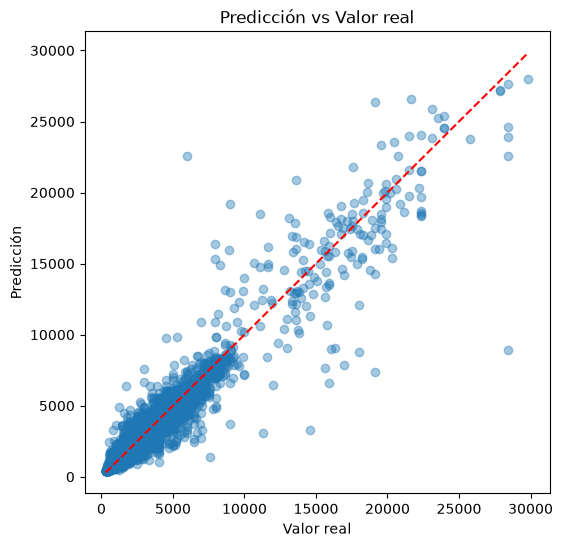

In [27]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, prediction, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("Predicción vs Valor real")

plt.show()

### Análisis de residuos

In [28]:
residuals = y_test - prediction

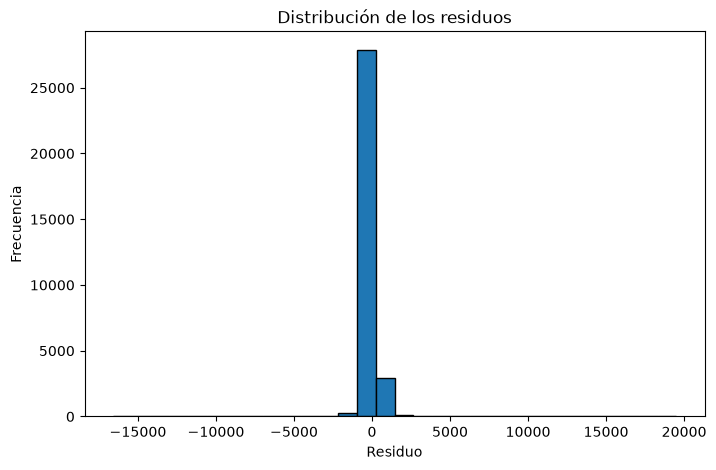

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    residuals,
    bins=30,
    edgecolor="black"
)

ax.set_title("Distribución de los residuos")
ax.set_xlabel("Residuo")
ax.set_ylabel("Frecuencia")

plt.show()

In [ ]:
### Donde se concentran los errores:

In [32]:
resultados = X_test.copy()

resultados["real"] = y_test.values
resultados["pred"] = prediction
resultados["error"] = abs(
    resultados["real"] -
    resultados["pred"]
)

In [38]:
resultados.groupby("producto_variedad")["error"].mean()

producto_variedad
aceituna_amarga           257.772486
aceituna_negra            283.979009
aceituna_sevillana        252.421260
arándano_blue            1137.566040
cereza_bing               411.673710
                            ...     
tuna                      194.193687
uva_flame_seedless        347.494620
uva_red_globe             240.987807
uva_superior_seedless     254.182104
uva_thompson_seedless     247.207115
Name: error, Length: 83, dtype: float64

In [34]:
resultados.groupby("region")["error"].mean()

region
región_de_arica_y_parinacota    220.743255
región_de_coquimbo              138.968008
región_de_la_araucanía          226.653809
región_de_los_lagos             193.271834
región_de_valparaíso            143.948993
región_de_ñuble                 176.640532
región_del_biobío               137.921871
región_del_maule                167.484595
región_metropolitana            184.978204
Name: error, dtype: float64

In [35]:
resultados.groupby("semana")["error"].mean()

semana
1     195.203362
2     232.293756
3     223.371166
4     244.329520
5     208.000145
6     178.462099
7     170.048965
8     179.419370
9     203.899527
10    207.796993
11    206.700237
12    157.955748
13    171.731889
14    178.512147
15    153.343043
16    149.622712
17    171.289374
18    175.253654
19    188.694314
20    159.366661
21    192.468325
22    175.118789
23    144.740604
24    152.588831
25    172.925379
26    166.142018
27    146.808826
28    155.516938
29    171.639295
30    153.016912
31    174.198414
32    134.468796
33    125.560645
34    132.665537
35    147.515308
36    154.564604
37    147.977455
38    156.051252
39    169.389957
40    142.369421
41    138.667394
42    145.624917
43    190.560871
44    175.440865
45    178.676281
46    171.839608
47    199.465169
48    231.435824
49    247.348362
50    261.063884
51    229.389764
52    232.811052
53    194.050766
Name: error, dtype: float64

### Importancia de las variables

El análisis de importancia permite estimar la contribución relativa de cada variable al proceso de predicción del modelo.

Este análisis no implica causalidad, sino únicamente cuánto utiliza el modelo cada característica durante el entrenamiento. Las variables con mayor importancia pueden ser consideradas candidatas prioritarias para un futuro análisis

In [40]:
from sklearn.inspection import permutation_importance

In [61]:
importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Variable": X_test.columns,
    "Importancia": importance.importances_mean
}).sort_values("Importancia", ascending=False)

importance_df

,Variable,Importancia
10,precio_lag_1,1.167255
5,producto_variedad,0.111202
2,tipo_punto_monitoreo,0.042068
4,anio,0.018582
0,semana,0.013800
3,calidad,0.004937
1,region,0.004935
6,temperature_2m_mean,0.001474
8,temperature_2m_min,0.000990
7,temperature_2m_max,0.000096


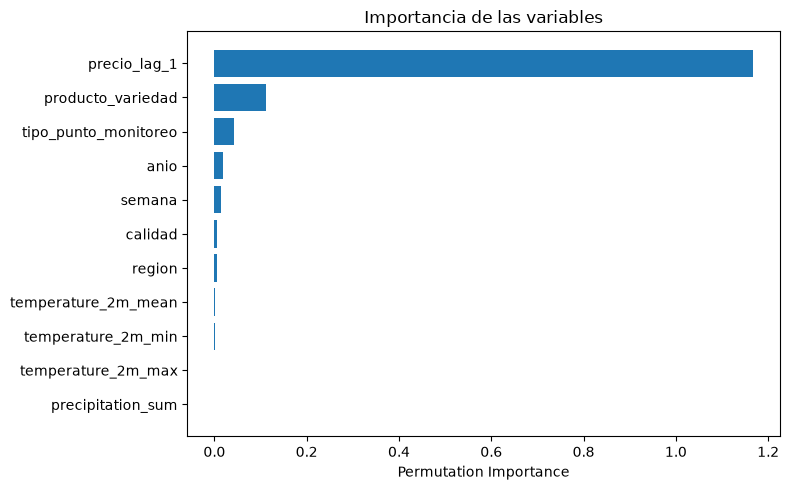

In [63]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    importance_df["Variable"],
    importance_df["Importancia"]
)

ax.invert_yaxis()

ax.set_title("Importancia de las variables")
ax.set_xlabel("Permutation Importance")

plt.tight_layout()
plt.show()

## Experimentos de ablación

Con el objetivo de comprender el aporte individual de determinados grupos de variables, se realizan experimentos eliminando características específicas y comparando el desempeño obtenido con el modelo original.

Este procedimiento permite evaluar si una variable realmente aporta información predictiva o si únicamente incrementa la complejidad del modelo sin mejorar su capacidad de generalización.

### Experimento 1: Eliminación de `precio_lag_1`

Debido a que `precio_lag_1` corresponde al precio observado durante la semana anterior, resulta esperable que posea una elevada capacidad predictiva. Este experimento busca cuantificar su influencia sobre el desempeño general del modelo.

In [84]:
categorical_cols = [
    "producto_variedad",
    "calidad",
    "region",
    "tipo_punto_monitoreo",
]
# a este tengo que aplicarle log +1
log_cols = [
    "precipitation_sum"
]

numerical_cols = [
    "semana",
    "anio",
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
]

scaled_numerical_cols = [
    c for c in numerical_cols
    if c not in log_cols
]

In [85]:
log_numeric = Pipeline([
    ("log", FunctionTransformer(np.log1p)),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        (
            "log",
            log_numeric,
            log_cols
        ),
        (
            "numeric",
            StandardScaler(),
            scaled_numerical_cols
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cols
        )
    ]
)

In [86]:
hist_gbr = HistGradientBoostingRegressor(
    random_state=42,
    max_iter=50
)

In [87]:
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", hist_gbr)
])


In [88]:
search = RandomizedSearchCV(

    estimator=pipeline,

    param_distributions=param_dist,

    n_iter=25,

    cv=5,

    scoring="neg_root_mean_squared_error",

    random_state=42,

    n_jobs=-1

)

In [89]:
X = df.drop(columns="precio_lag_1")

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [91]:
search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [None, 5, ...], 'model__max_iter': [100, 200, ...], 'model__max_leaf_nodes': [15, 31, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` direct

In [92]:
best_model = search.best_estimator_

In [93]:
prediction_2 = best_model.predict(X_test)

In [94]:
print("R² :", r2_score(y_test,prediction_2))

print("MAE :", mean_absolute_error(
    y_test,
    prediction_2
))

print("RMSE :", root_mean_squared_error(
    y_test,
    prediction_2
))

R² : 0.9357120308872325
MAE : 221.46585949452117
RMSE : 439.0528592784422


In [106]:
comparacion = pd.DataFrame({
    "Métrica": ["R²", "MAE", "RMSE"],
    "Con precio_lag_1": [
        r2_score(y_test,prediction),
        mean_absolute_error(
            y_test,
            prediction
        ),
        root_mean_squared_error(
            y_test,
            prediction
        )
    ],
    "Sin precio_lag_1": [
        r2_score(y_test,prediction_2),
        mean_absolute_error(
            y_test,
            prediction_2
        ),
        root_mean_squared_error(
            y_test,
            prediction_2
        )
    ]
})

comparacion

,Métrica,Con precio_lag_1,Sin precio_lag_1
0,R²,0.938282,0.935712
1,MAE,181.278529,221.465859
2,RMSE,430.188409,439.052859


### Experimento 2: Eliminación de las variables meteorológicas

Las variables meteorológicas fueron incorporadas bajo la hipótesis de que las condiciones climáticas podrían afectar la producción agrícola y, en consecuencia, el precio de los productos.

Este experimento evalúa si dicha información mejora efectivamente la capacidad predictiva del modelo.

In [108]:
categorical_cols = [
    "producto_variedad",
    "calidad",
    "region",
    "tipo_punto_monitoreo",
]

numerical_cols = [
    "semana",
    "anio",
]

scaled_numerical_cols = [
    c for c in numerical_cols
]

In [109]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            scaled_numerical_cols
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cols
        )
    ]
)

In [110]:
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", hist_gbr)
])

In [111]:
search = RandomizedSearchCV(

    estimator=pipeline,

    param_distributions=param_dist,

    n_iter=25,

    cv=5,

    scoring="neg_root_mean_squared_error",

    random_state=42,

    n_jobs=-1

)

In [113]:
X = df.drop(columns=
            [ "precipitation_sum",
              "temperature_2m_mean",
              "temperature_2m_max",
              "temperature_2m_min"
            ])

In [114]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [115]:
search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [None, 5, ...], 'model__max_iter': [100, 200, ...], 'model__max_leaf_nodes': [15, 31, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` direct

In [116]:
best_model = search.best_estimator_

In [117]:
prediction_3 = best_model.predict(X_test)

In [118]:
comparacion = pd.DataFrame({
    "Métrica": ["R²", "MAE", "RMSE"],
    "Sin precio_lag_1": [
        r2_score(y_test,prediction_2),
        mean_absolute_error(
            y_test,
            prediction_2
        ),
        root_mean_squared_error(
            y_test,
            prediction_2
        )
    ],
      "Sin meteo": [
        r2_score(y_test,prediction_3),
        mean_absolute_error(
            y_test,
            prediction_3
        ),
        root_mean_squared_error(
            y_test,
            prediction_3
        )
    ]
})

comparacion

,Métrica,Sin precio_lag_1,Sin meteo
0,R²,0.935712,0.936962
1,MAE,221.465859,217.201000
2,RMSE,439.052859,434.762798


Mejora en todas las métricas al retirar las variables meteorológicas

# Conclusiones generales

El modelo obtuvo un coeficiente de determinación superior al 93%, lo que indica una elevada capacidad para explicar la variabilidad del precio semanal de los productos agrícolas considerados.

El análisis de importancia de variables y los experimentos de ablación permitieron identificar que `precio_lag_1` constituye uno de los predictores más relevantes del modelo. Su eliminación produjo un deterioro consistente en todas las métricas de evaluación, evidenciando la fuerte dependencia temporal presente en la serie de precios.

En contraste, las variables meteorológicas mostraron una contribución limitada. Bajo la configuración utilizada, su eliminación produjo diferencias mínimas e incluso una ligera mejora en el desempeño. Esto sugiere que la información climática disponible no aporta suficiente información adicional al modelo, posiblemente porque su efecto ya se encuentra parcialmente reflejado en el comportamiento histórico de los precios o porque el impacto del clima ocurre con un desfase temporal que no fue considerado durante este estudio.

En conjunto, los resultados indican que las variables históricas del propio mercado poseen una capacidad predictiva considerablemente mayor que las variables meteorológicas empleadas.

Como trabajo futuro podrían evaluarse:

- Variables meteorológicas con rezagos temporales.Lag para el último mes o si fuera posible conseguir la data: condiciones climáticas durante la epoca de cosecha (complicado)
- Variables económicas como IPC u otros indicadores de mercado.
- Técnicas adicionales de selección de características.